In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [41]:
import pandas as pd

df = pd.read_csv("/Users/dylantoplas/Documents/ds4420/DS4420Project/bonds_dashboards/fred_md.csv")

df = df.iloc[1:,:]  # drop first column


df['sasdate'] = pd.to_datetime(df['sasdate'])

gs2 = pd.read_csv("/Users/dylantoplas/Documents/ds4420/DS4420Project/bonds_dashboards/GS2.csv")
gs2['observation_date'] = pd.to_datetime(gs2['observation_date'])

df = df.merge(gs2[['observation_date', 'GS2']], left_on='sasdate', right_on='observation_date', how='inner')

# df

In [42]:
data = df.copy()
data = data.dropna()

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400 entries, 188 to 588
Columns: 129 entries, sasdate to GS2
dtypes: datetime64[ns](2), float64(103), int64(24)
memory usage: 406.2 KB


['GS1', 'GS5', 'GS10', 'GS2']


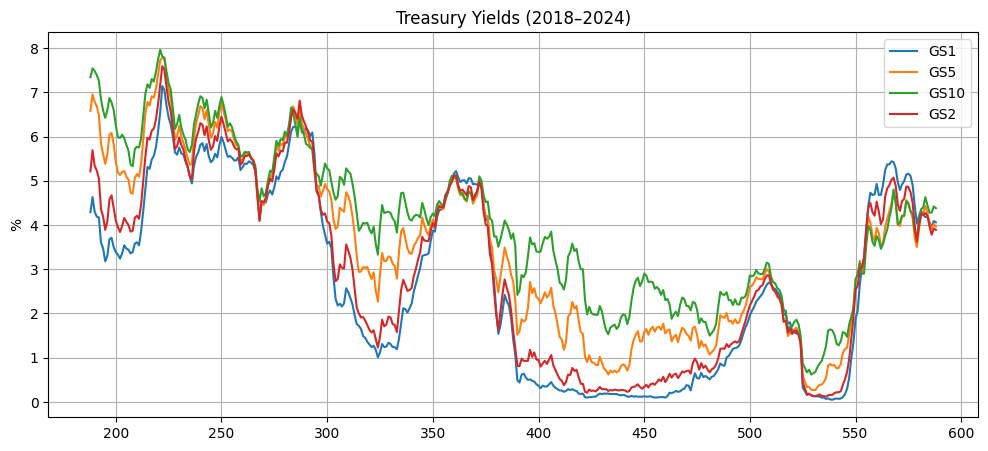

In [43]:
yield_cols = [c for c in data.columns if "GS" in c]
yield_cols.remove("TWEXAFEGSMTHx")
print(yield_cols)

plt.figure(figsize=(12,5))
for col in yield_cols:
    plt.plot(data.index, data[col], label=col)

plt.title("Treasury Yields (2018–2024)")
plt.ylabel("%")
plt.legend()
plt.grid(True)
plt.show()

In [44]:
# New features

features = ['CPIAUCSL', 'UNRATE', 'PAYEMS', 'INDPRO', 'FEDFUNDS', 'RPI', 'S&P 500', 'HOUST']
data = data[features + yield_cols]

data['10Y_2Y_spread'] = data['GS10'] - data['GS2']
data['10Y_5Y_spread'] = data['GS10'] - data['GS5']

for feature in features:
    data[f'{feature}_lag1'] = data[feature].shift(1)
    data[f'{feature}_lag2'] = data[feature].shift(2)
    data[f'{feature}_lag3'] = data[feature].shift(3)

for feature in features:
    data[f'{feature}_ma3'] = data[feature].rolling(3).mean()
    data[f'{feature}_ma12'] = data[feature].rolling(12).mean()
# Drop NaN rows after creating lags
data = data.dropna()

In [45]:
train = data.iloc[:-12, :]
test  = data.iloc[-12:, :]

X_train = train.drop(columns=yield_cols)
X_test  = test.drop(columns=yield_cols)

y_train = train[yield_cols]
y_test  = test[yield_cols]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (377, 50)
y_train: (377, 4)
X_test: (12, 50)
y_test: (12, 4)


In [46]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [93]:
mean_pred = np.tile(y_train.mean().values, (len(y_test), 1))

baseline_rmse = np.sqrt(mean_squared_error(y_test, mean_pred))
print(f'Baseline RMSE: {baseline_rmse}')

baseline_mae = mean_absolute_error(y_test, mean_pred)
print(f'Baseline MAE: {baseline_mae}')

Baseline RMSE: 1.0466158405018064
Baseline MAE: 0.9170418877099912


In [90]:
# plt.figure(figsize=(10,4))
# plt.plot(y_test.index, y_test, label="Actual")
# plt.plot(y_test.index, mean_pred, label="Mean baseline")
# plt.title("Baseline Prediction vs Actual (10Y Yield)")
# plt.legend()
# plt.grid(True)
# plt.show()

In [49]:
# intercept
Xb = np.column_stack([np.ones(X_train_scaled.shape[0]), X_train_scaled])
Xt = np.column_stack([np.ones(X_test_scaled.shape[0]), X_test_scaled])

beta = np.linalg.pinv(Xb.T @ Xb) @ (Xb.T @ y_train.values)

beta[:5]

array([[ 2.68496021,  3.42188329,  3.92159151,  2.90976127],
       [-1.06048952, -0.45673705, -0.45673705, -0.45673705],
       [-0.04516248,  0.02172309,  0.02172309,  0.02172309],
       [-0.04988175,  0.22138526,  0.22138526,  0.22138526],
       [ 0.06208372,  0.05968096,  0.05968096,  0.05968096]])

In [96]:
lr_pred = Xt @ beta
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
print(f'Linear Regression RMSE: {lr_rmse}')

lr_mae = mean_absolute_error(y_test, lr_pred)
print(f'Linear Regression MAE: {lr_mae}')

Linear Regression RMSE: 0.3911481615278253
Linear Regression MAE: 0.2928127836016465


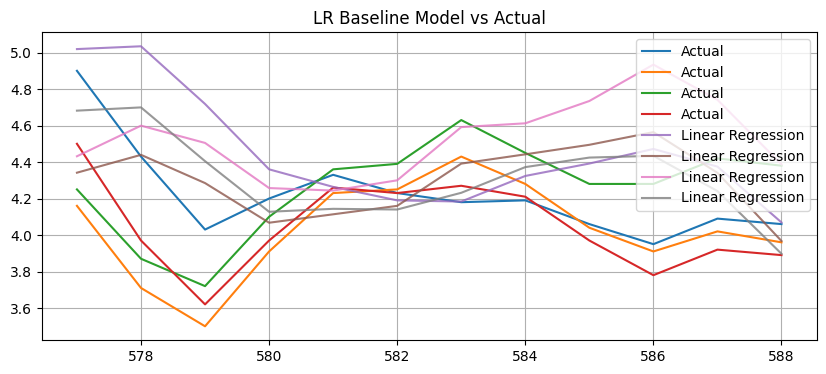

In [52]:
plt.figure(figsize=(10,4))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, lr_pred, label="Linear Regression", alpha=0.8)
plt.title("LR Baseline Model vs Actual")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
class SimpleNN:
    def __init__(self, input_dim, hidden_dim=64, lr=0.001, output_dim=None):

        self.W1 = np.random.randn(input_dim, hidden_dim) / np.sqrt(input_dim)
        self.b1 = np.zeros(hidden_dim)

        self.W2 = np.random.randn(hidden_dim, output_dim) / np.sqrt(hidden_dim)
        self.b2 = np.zeros(output_dim)

        self.lr = lr
        self.errors = []

    def relu(self, x):
        return np.maximum(0, x)

    def relu_deriv(self, x):
        return (x > 0).astype(float)

    def train(self, X, y, epochs=200):
        for e in range(epochs):
            z1 = X @ self.W1 + self.b1
            a1 = self.relu(z1)
            z2 = a1 @ self.W2 + self.b2
            pred = z2

            loss = np.mean((pred - y)**2)

            dloss = 2 * (pred - y) / len(y)

            dW2 = a1.T @ dloss
            db2 = dloss.sum(axis=0)

            da1 = dloss @ self.W2.T
            dz1 = da1 * self.relu_deriv(z1)

            dW1 = X.T @ dz1
            db1 = dz1.sum(axis=0)

            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2
            self.errors.append(loss)

    def predict(self, X):
        return self.relu(X @ self.W1 + self.b1) @ self.W2 + self.b2

In [60]:
nn = SimpleNN(
    input_dim=X_train_scaled.shape[1],
    hidden_dim=16,
    lr=0.001,
    output_dim=len(yield_cols)
)

In [66]:
nn.train(X_train_scaled, y_train.values, epochs=500)

In [94]:
nn_pred = nn.predict(X_test_scaled)
nn_rmse = np.sqrt(mean_squared_error(y_test, nn_pred))
print(f'Neural Network RMSE: {nn_rmse}')

nn_mae = mean_absolute_error(y_test, nn_pred)
print(f'Neural Network MAE: {nn_mae}')

Neural Network RMSE: 0.31890615945248124
Neural Network MAE: 0.2714562839300251


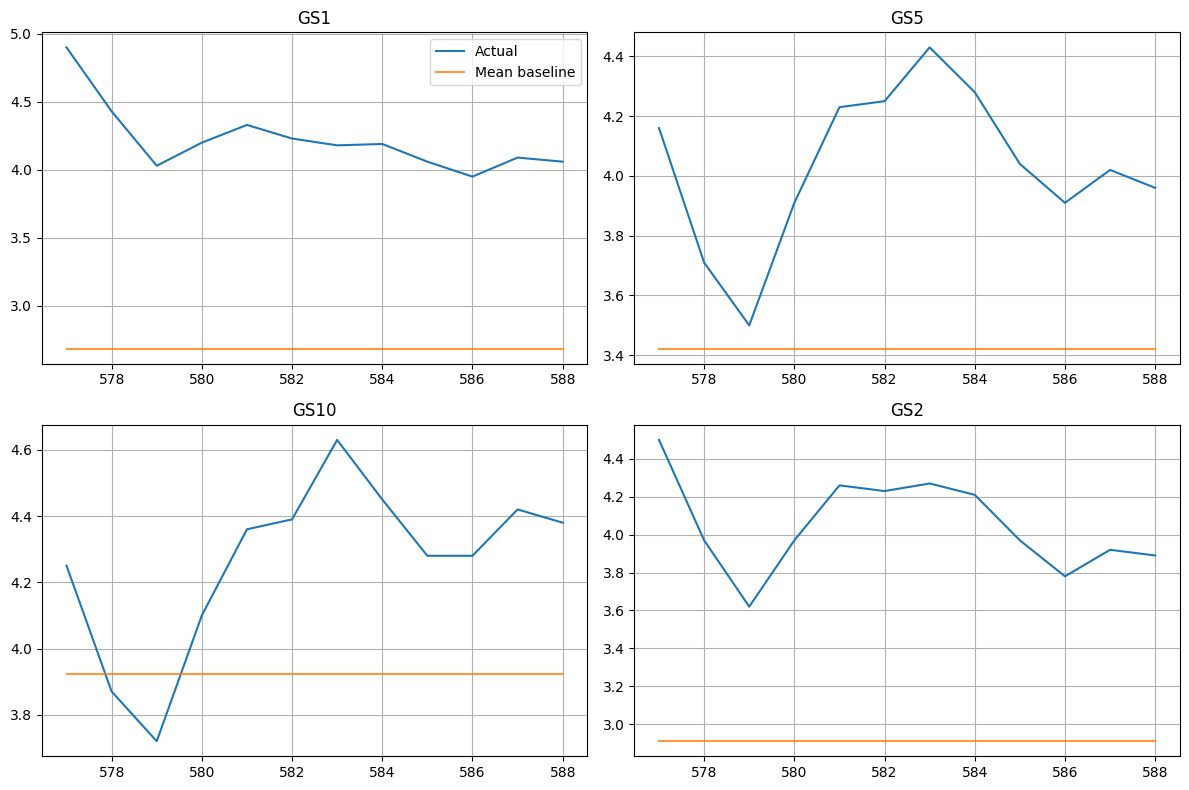

In [68]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(yield_cols):
    plt.subplot(2, 2, i+1)
    plt.plot(y_test.index, y_test[col], label="Actual")
    plt.plot(y_test.index, mean_pred[:, i], label="Mean baseline", alpha=0.8)
    plt.title(col)
    plt.grid(True)
    if i == 0:
        plt.legend()

plt.tight_layout()
plt.show()

In [98]:
print("BASELINE RMSEs (Last Year test period)")
print("--------------------------------------")
print(f"Mean baseline:         {baseline_rmse:.4f}")
print(f"Linear Regression:     {lr_rmse:.4f}")
print(f"Manual Neural Network: {nn_rmse:.4f}")
print()
print("BASELINE MAEs (Last Year test period)")
print("--------------------------------------")
print(f"Mean baseline:         {baseline_mae:.4f}")
print(f"Linear Regression:     {lr_mae:.4f}")
print(f"Manual Neural Network: {nn_mae:.4f}")

BASELINE RMSEs (Last Year test period)
--------------------------------------
Mean baseline:         1.0466
Linear Regression:     0.3911
Manual Neural Network: 0.3189

BASELINE MAEs (Last Year test period)
--------------------------------------
Mean baseline:         0.9170
Linear Regression:     0.2928
Manual Neural Network: 0.2715


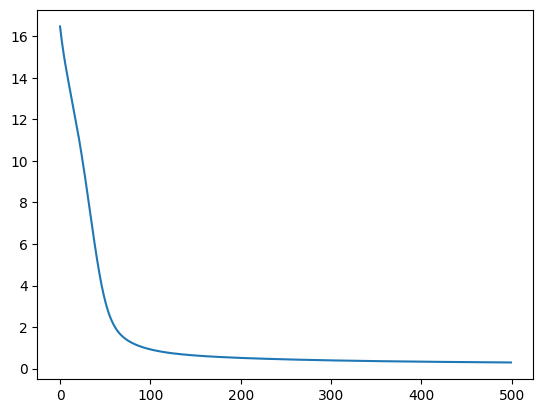

In [71]:
plt.plot(nn.errors)

In [87]:
y_test.shape

(12, 4)

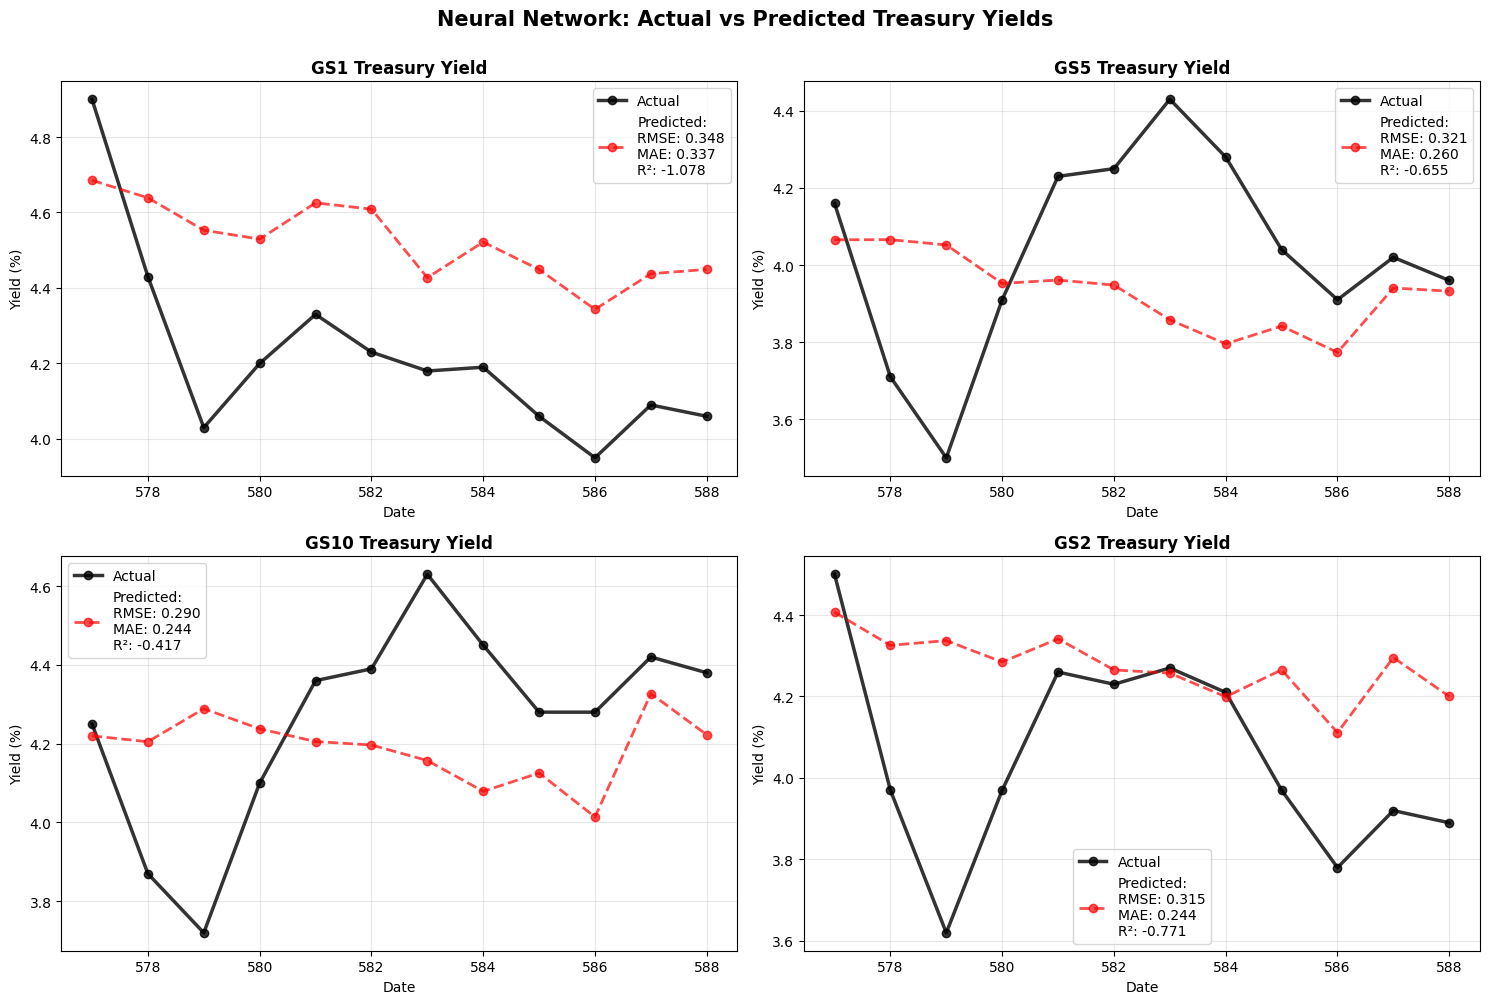

In [86]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler



fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(yield_cols):
    rmse = np.sqrt(mean_squared_error(y_test[col], nn_pred[:, i]))
    mae = mean_absolute_error(y_test[col], nn_pred[:, i])
    r2 = r2_score(y_test[col], nn_pred[:, i])

    ax = axes[i]
    
    ax.plot(y_test.index, y_test[col], 
            label='Actual', color='black', linewidth=2.5, 
            marker='o', markersize=6, alpha=0.8)
    
    ax.plot(y_test.index, nn_pred[:, i], 
            label=f'Predicted:\nRMSE: {rmse:.3f}\nMAE: {mae:.3f}\nR²: {r2:.3f}', color='red', linewidth=2, 
            marker='o', markersize=6, alpha=0.7, linestyle='--')
    
   
    
    ax.set_title(f'{col} Treasury Yield', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Yield (%)', fontsize=10)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)


plt.suptitle(f'Neural Network: Actual vs Predicted Treasury Yields', 
            fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()



In [88]:
nn_pred_df = pd.DataFrame(
    nn_pred,
    index=y_test.index,
    columns=[col + "_pred" for col in yield_cols]
)

nn_pred_df.to_csv("../data/nn_predictions_multi_output_2018_2024.csv")